# 04_extra_baseline_logreg.ipynb — Extra baseline (Logistic Regression)

Στόχος:
- Να δοκιμάσουμε έναν κλασικό ML estimator (Multinomial Logistic Regression)
- Να συγκρίνουμε αποτελέσματα με τα Bayesian Networks Naive Bayes BN
- Να αξιολογήσουμε σωστά λόγω multi-class imbalance:
  - Accuracy
  - Macro F1 / Weighted F1
  - MCC (multi-class)
  - Confusion matrix
  - ROC curves (One-vs-Rest) + Macro AUC


In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent
PROCESSED_DIR = ROOT / "API-Data" / "processed"

TRAIN_CSV = PROCESSED_DIR / "dataset_paper_train.csv"
TEST_CSV  = PROCESSED_DIR / "dataset_paper_test.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

TARGET = "duration_class"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

print("Classes:", sorted(y_train.unique()))


Train: (122002, 24) (122002,)
Test : (7483, 24) (7483,)
Classes: ['0 day', '1-2 days', '11-17 days', '18+ days', '3 days', '4 days', '5 days', '6-7 days', '8-10 days']


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Greeklish comments:
# OLA ta features einai categorical (strings/0-1). Tha ta kanoume OneHot.
cat_cols = X_train.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)

logreg = LogisticRegression(
    multi_class="multinomial",
    solver="saga",
    max_iter=1000,      # αντί για 2000
    class_weight="balanced",
    n_jobs=-1
)


model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", logreg)
])

print(model)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Flag', 'ShipType',
                                                   'PSCInspectionType',
                                                   'PlaceOfInspection',
                                                   'ReportingAuthority',
                                                   'ship_age_group', 'gt_group',
                                                   'def_grp_01', 'def_grp_02',
                                                   'def_grp_03', 'def_grp_04',
                                                   'def_grp_05', 'def_grp_06',
                                                   'def_grp_07', 'def_grp_08',
                                                   'def_grp_09', 'def_grp_10',
                                                   'def_grp_11',

In [3]:
model.fit(X_train, y_train)
print("Trained Logistic Regression.")


C:\Users\georg\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Trained Logistic Regression.


C:\Users\georg\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [4]:
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, matthews_corrcoef
)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
mcc = matthews_corrcoef(y_test, y_pred)  # works multi-class

print("Accuracy:", round(acc, 4))
print("Macro F1:", round(f1_macro, 4))
print("Weighted F1:", round(f1_weighted, 4))
print("MCC:", round(mcc, 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y_train.unique()))
print("\nConfusion matrix:")
print(cm)


Accuracy: 0.7268
Macro F1: 0.1371
Weighted F1: 0.8221
MCC: 0.1727

Classification report:
              precision    recall  f1-score   support

       0 day      0.996     0.750     0.855      7174
    1-2 days      0.013     0.143     0.024        28
  11-17 days      0.037     0.347     0.068        49
    18+ days      0.056     0.480     0.100        50
      3 days      0.024     0.233     0.043        30
      4 days      0.018     0.030     0.023        33
      5 days      0.012     0.067     0.021        30
    6-7 days      0.011     0.087     0.020        46
   8-10 days      0.094     0.070     0.080        43

    accuracy                          0.727      7483
   macro avg      0.140     0.245     0.137      7483
weighted avg      0.956     0.727     0.822      7483


Confusion matrix:
[[5377  300  376  335  270   47  143  309   17]
 [   5    4    4    8    2    1    1    3    0]
 [   0    0   17   21    1    2    4    2    2]
 [   0    1   14   24    1    0    1    6 

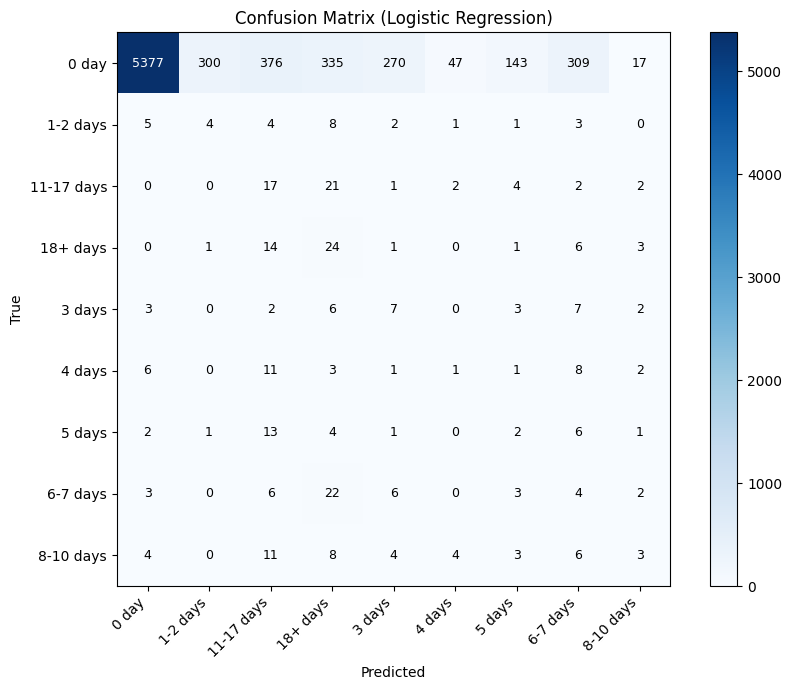

In [5]:
import numpy as np
import matplotlib.pyplot as plt

labels = sorted(y_train.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(9, 7))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

max_val = cm.max() if cm.max() > 0 else 1
thr = max_val * 0.5

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        color = "white" if val > thr else "black"
        plt.text(j, i, str(val), ha="center", va="center", fontsize=9, color=color)

plt.colorbar()
plt.tight_layout()
plt.show()


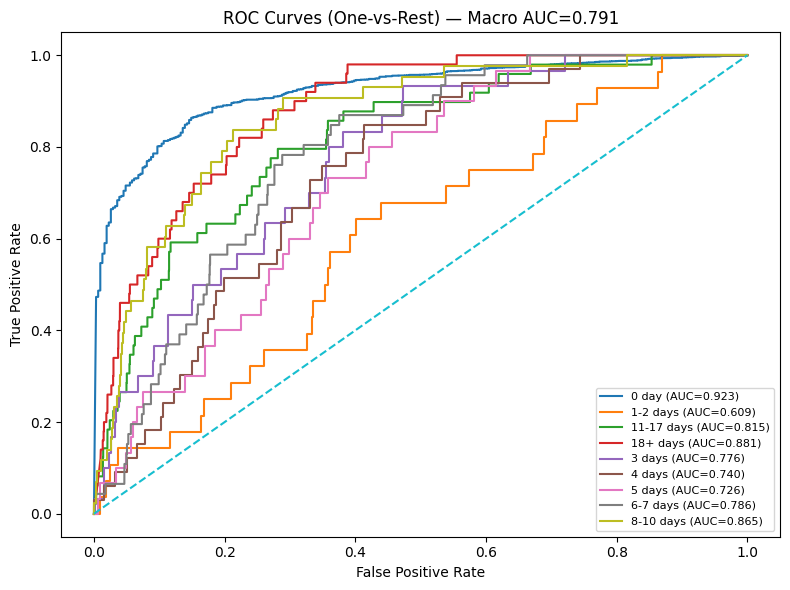

Macro AUC: 0.7912


In [6]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# predict_proba (multiclass)
proba = model.predict_proba(X_test)

labels = model.named_steps["clf"].classes_
y_test_bin = label_binarize(y_test, classes=labels)

plt.figure(figsize=(8, 6))

aucs = []
for i, cls in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

# macro-average AUC (simple average of per-class AUCs)
macro_auc = float(np.mean(aucs))

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curves (One-vs-Rest) — Macro AUC={macro_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Macro AUC:", round(macro_auc, 4))


Προσθέσαμε έναν κλασικό, ερμηνεύσιμο baseline (multinomial Logistic Regression) με εξισορρόπηση κλάσεων ώστε να έχουμε σημείο αναφοράς (benchmark) 
απέναντι στα Bayesian Network μοντέλα σε συνθήκες έντονης πολυ-κλασικής ανισορροπίας